In [1]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential



In [2]:
# Define paths to your dataset directories
dataset_dir = '../output_images'  # Update this to your main directory

batch_size = 32
img_height = 30
img_width = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
  dataset_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  dataset_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 102 files belonging to 2 classes.
Using 82 files for training.
Found 102 files belonging to 2 classes.
Using 20 files for validation.


In [3]:
class_names = train_ds.class_names
print(class_names)

['l2r', 'r2l']


In [4]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [5]:
normalization_layer = layers.Rescaling(1./255)

In [6]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))

In [7]:
# Create model
num_classes = len(class_names)

model = Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes)
])

c:\Users\awebb\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
# Compile model
model.compile(optimizer=keras.optimizers.Adam(learning_rate=2e-4),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [9]:
# model.summary()

In [10]:
# Train model
epochs=10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - accuracy: 0.5395 - loss: 0.6872 - val_accuracy: 0.3500 - val_loss: 0.7053
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5696 - loss: 0.6593 - val_accuracy: 0.3500 - val_loss: 0.6670
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6822 - loss: 0.6093 - val_accuracy: 0.5000 - val_loss: 0.6416
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7997 - loss: 0.5891 - val_accuracy: 0.7500 - val_loss: 0.6098
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8879 - loss: 0.5545 - val_accuracy: 0.8000 - val_loss: 0.5749
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8726 - loss: 0.5139 - val_accuracy: 0.9500 - val_loss: 0.5235
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9467 - loss: 0.4620 - val_accuracy: 1.0000 - val_loss: 0.4589
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.3981 - val_accuracy: 1.0000 - val_loss: 0.3980

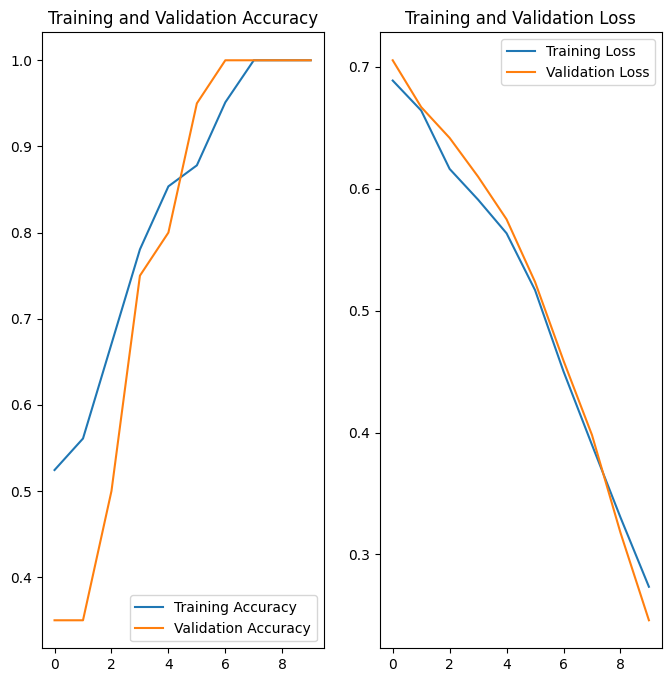

In [11]:
# Visualize training process
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [12]:
import mediapipe as mp
import random

In [14]:
# My testing
from PIL import Image
import numpy as np

# Load the image using PIL
print("Predicted | Actual")

numToDetect = 50
correct = 0

# img_path = fr'C:\Users\awebb\Documents\Programming\Python\Unnamed\sample_0.jpg'
# img = Image.open(img_path)

# img = img.resize((img_width, img_height))

# # Convert the image to a NumPy array
# img_array = np.array(img)

# # Add a batch dimension (model expects a batch of images)
# img_array = np.expand_dims(img_array, axis=0)

# Make a prediction
# predictions = model.predict(img_array, verbose=0)

# probabilities = tf.nn.softmax(predictions[0])
# predicted_class = class_names[np.argmax(probabilities)]

# print(predicted_class)

for i in range(numToDetect):
    classToDetect = 'r2l' if random.random() > 0.5 else 'l2r'
    img_path = fr'C:\Users\awebb\Documents\Programming\Python\Unnamed\output_images\{classToDetect}\sample_{i}.jpg'
    img = Image.open(img_path)

    # Resize the image to the same size as the model input
    img = img.resize((img_width, img_height))

    # Convert the image to a NumPy array
    img_array = np.array(img)

    # Add a batch dimension (model expects a batch of images)
    img_array = np.expand_dims(img_array, axis=0)

    # Make a prediction
    predictions = model.predict(img_array, verbose=0)

    probabilities = tf.nn.softmax(predictions[0])
    predicted_class = class_names[np.argmax(probabilities)]
    
    print(f"{predicted_class}  | {classToDetect}  | {predicted_class == classToDetect}")

    correct += (1 if predicted_class == classToDetect else 0)

print("Summary:")
print(f'Percent Correct: {correct/numToDetect}')


Predicted | Actual
l2r  | l2r  | True
r2l  | r2l  | True
r2l  | r2l  | True
l2r  | l2r  | True
r2l  | r2l  | True
l2r  | l2r  | True
l2r  | l2r  | True
l2r  | l2r  | True
l2r  | l2r  | True
r2l  | r2l  | True
l2r  | l2r  | True
r2l  | r2l  | True
l2r  | l2r  | True
r2l  | r2l  | True
r2l  | r2l  | True
l2r  | l2r  | True
r2l  | r2l  | True
l2r  | l2r  | True
l2r  | l2r  | True
r2l  | r2l  | True
l2r  | l2r  | True
l2r  | l2r  | True
l2r  | l2r  | True
l2r  | l2r  | True
r2l  | r2l  | True
r2l  | r2l  | True
l2r  | l2r  | True
r2l  | r2l  | True
r2l  | r2l  | True
r2l  | r2l  | True
l2r  | l2r  | True
l2r  | l2r  | True
l2r  | l2r  | True
l2r  | l2r  | True
r2l  | r2l  | True
r2l  | r2l  | True
r2l  | r2l  | True
l2r  | l2r  | True
r2l  | r2l  | True
l2r  | l2r  | True
r2l  | r2l  | True
r2l  | r2l  | True
r2l  | r2l  | True
r2l  | r2l  | True
l2r  | l2r  | True
l2r  | l2r  | True
r2l  | r2l  | True
r2l  | r2l  | True
l2r  | l2r  | True
l2r  | l2r  | True
Summary:
Percent Correct: 1.0


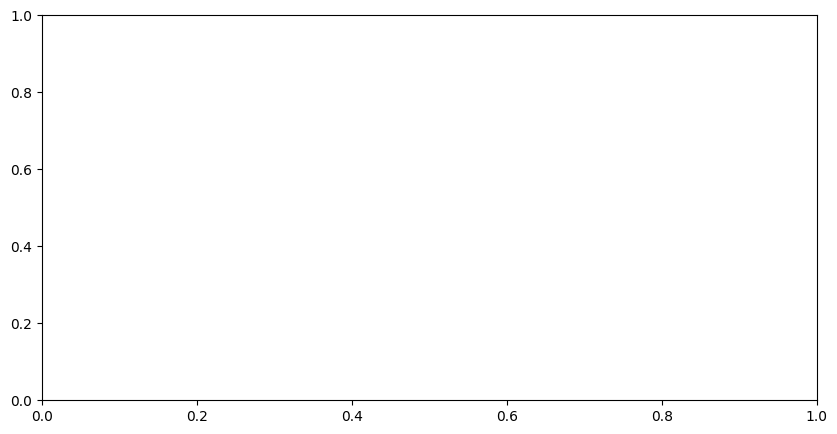

In [15]:
from TemporalMap import TemporalMap

tmapMaker = TemporalMap(RENDER_TMAPS=True, MODEL_PATH=r'C:\Users\awebb\Documents\Programming\Python\Unnamed\models\hand_landmarker.task')

tmapMaker.setup()


In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from PIL import Image
from tensorflow.keras.preprocessing import image

# Open the default camera
cam = cv2.VideoCapture(0)

while True:
    # Capture frame-by-frame from the camera
    ret, frame = cam.read()

    # Display the captured frame
    cv2.imshow('Camera', frame)

    # Convert frame to mediapipe image
    mpFrame = tmapMaker.convertImageToMediapipeImage(frame)

    # Calculate hand landmarks
    handLandmarks = tmapMaker.calculateHandLandmarks(mpFrame)

    # Calculate and append the new Timg (temporal image) to the tmap
    tmapMaker.tmap.append(tmapMaker.calculateTimg(handLandmarks))

    # Refresh the temporal map visualization
    tmapMaker.refreshTmap()

    # Convert the tmap (2D array with RGB values) into a format suitable for PIL
    # Assuming tmap is a valid image array (Height x Width x Channels)
    tmap_array = np.array(tmapMaker.tmap)

    # Convert the NumPy array to PIL Image
    img = Image.fromarray(tmap_array.astype('uint8'), 'RGB')

    # Resize the image to match the model's input dimensions
    img = img.resize((img_width, img_height))

    # Convert the resized PIL image to a NumPy array
    img_array = image.img_to_array(img)

    # Add a batch dimension (model expects a batch of images)
    img_array = np.expand_dims(img_array, axis=0)

    # Make a prediction using the model
    predictions = model.predict(img_array, verbose=0)

    # Convert logits to probabilities using softmax
    probabilities = tf.nn.softmax(predictions[0])
    predictedClass = class_names[np.argmax(probabilities)]

    # Print the predicted class
    print(predictedClass)

    # Press 'q' to exit the loop
    if cv2.waitKey(1) == ord('q'):
        break

# Release the capture and close all OpenCV windows
cam.release()
cv2.destroyAllWindows()


In [25]:
cam.release()